[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pablolob/calc_dif_equations_LAB/blob/main/06_Neurona_LIF.ipynb)

# 🧠 LAB 6: Neurona Integrate-and-Fire — Cómo Pensamos en Spikes

Cada pensamiento, cada movimiento y cada recuerdo empieza con un **pulso eléctrico** en una neurona. La neurona acumula corriente como un condensador hasta que cruza un umbral... y entonces dispara un *spike*.

**El caso clínico**: Una neurona de la retina recibe corriente $I$ proporcional a la intensidad de luz. La membrana acumula tensión según una EDO lineal de primer orden:

$$\tau_m \frac{dV}{dt} = -(V - V_{rest}) + R_m\, I$$

Cuando $V$ alcanza el umbral $V_{th}$, la neurona dispara un spike y se *resetea* a $V_{reset}$. Tu misión: implementar el modelo y descubrir cómo la **frecuencia de spikes** codifica la intensidad del estímulo.

---

In [1]:
# !!! ESTA CELDA ES SOLO DE CONFIGURACIÓN.
# Este bloque contiene código auxiliar; ejecútalo para poder visualizar los resultados más adelante.
import numpy as np
import matplotlib.pyplot as plt

# Parámetros biofísicos típicos de una neurona
TAU   = 10.0       # constante de tiempo de la membrana (ms)
V_REST   = -70.0   # potencial de reposo (mV)
V_TH     = -55.0   # umbral de disparo (mV)
V_RESET  = -75.0   # potencial tras el spike (mV)
RM       = 10.0    # resistencia de membrana (MΩ)
V_SPIKE  = 30.0    # altura del spike (solo para visualizar)

def dibujar_traza(t, V, spikes, I):
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.axhline(V_TH, color='red', linestyle='--', alpha=0.6, label=f'Umbral $V_{{th}}$ = {V_TH} mV')
    ax.axhline(V_REST, color='gray', linestyle=':', alpha=0.6, label=f'Reposo $V_{{rest}}$ = {V_REST} mV')
    ax.plot(t, V, 'b-', lw=1.4)
    for ts in spikes:
        ax.plot([ts, ts], [V_TH, V_SPIKE], 'b-', lw=1.4)
    ax.set_xlabel('Tiempo (ms)'); ax.set_ylabel('V(t) (mV)')
    ax.set_title(f'Trayectoria de la membrana   |   I = {I:.2f} nA   |   {len(spikes)} spikes')
    ax.legend(loc='lower right'); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def dibujar_curva_FI(corrientes, frecuencias, I_reo=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(corrientes, frecuencias, 'o-', color='purple', lw=2, markersize=6)
    if I_reo is not None:
        ax.axvline(I_reo, color='red', linestyle='--', alpha=0.7,
                   label=f'Corriente reobásica $I_{{reo}}$ = {I_reo:.2f} nA')
    ax.set_xlabel('Corriente de entrada I (nA)')
    ax.set_ylabel('Frecuencia de spikes (Hz)')
    ax.set_title('Curva F-I: la neurona como conversor analógico-digital')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

## 🔬 La Receta del Modelo LIF

La neurona se simula con dos reglas:

1. **Integración** (mientras $V < V_{th}$): aplicamos Euler a la EDO
$$V_{n+1} = V_n + \frac{\Delta t}{\tau_m}\Big[-(V_n - V_{rest}) + R_m I\Big]$$

2. **Disparo + reset** (cuando $V \geq V_{th}$): registramos el tiempo de spike y forzamos $V \leftarrow V_{reset}$.

<details>
<summary><b>Corriente reobásica — ¿la mínima para disparar?</b></summary>

Si esperamos mucho tiempo con corriente $I$ constante, la membrana llega al estado estacionario $\tfrac{dV}{dt}=0$:

$$V_{\infty} = V_{rest} + R_m I$$

Para que la neurona llegue a disparar necesitamos $V_{\infty} \geq V_{th}$, lo que da:

$$\boxed{I_{reo} = \frac{V_{th} - V_{rest}}{R_m}}$$

Si $I < I_{reo}$, la neurona nunca dispara: la curva $V(t)$ se asienta por debajo del umbral.
</details>

---

### 🛠️ ¡TU TURNO! — Simula la neurona

1. Implementa el **paso de Euler** del LIF
2. Añade la **condición de reset**: si $V \geq V_{th}$, registra el tiempo de spike y vuelve a $V_{reset}$

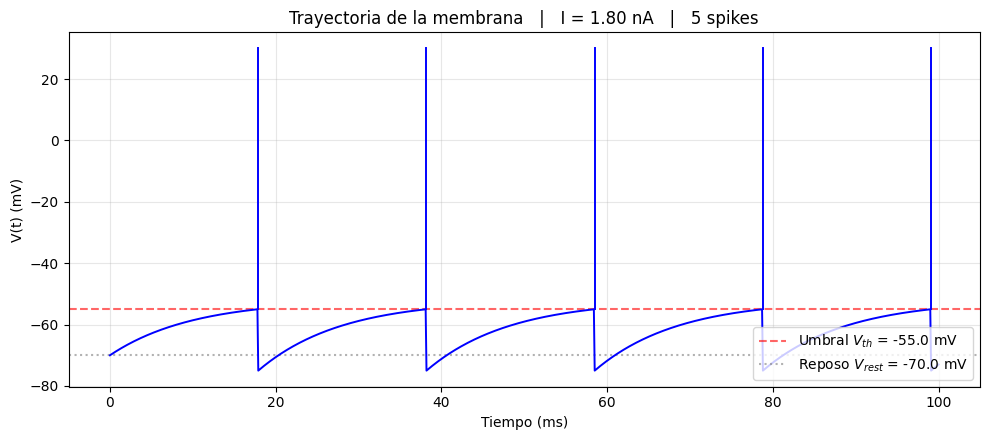

In [ ]:
I = 1.8        # corriente de entrada (nA) — prueba luego con 0.5 y con 3.0
T_final = 100  # ms
dt = 0.1       # ms

n_pasos = int(T_final / dt)
t = np.linspace(0, T_final, n_pasos + 1)
V = np.zeros(n_pasos + 1)
V[0] = V_REST
spikes = []

for n in range(n_pasos):
    derivada = (-(V[n] - V_REST) + RM * I) / TAU
    V[n+1] = None     # <--- ¡Tu turno 1! Paso de Euler

    # <--- ¡Tu turno 2! Si V[n+1] cruza el umbral V_TH:
    #   - guarda el tiempo del spike en la lista 'spikes'  (usa t[n+1])
    #   - resetea V[n+1] a V_RESET

dibujar_traza(t, V, spikes, I)

<details>
<summary><b>¿Atascado? Haz clic aquí para ver la Solución</b></summary>

```python
V[n+1] = V[n] + dt * derivada

if V[n+1] >= V_TH:
    spikes.append(t[n+1])
    V[n+1] = V_RESET
```
</details>

### 🔍 La Curva F-I — La neurona codifica intensidad

Si la simulación funciona, la celda siguiente la repetirá para distintas corrientes y construirá la **curva F-I**: cuántos spikes por segundo se producen en función de la intensidad del estímulo.

Antes calculamos analíticamente la corriente reobásica para compararla:

Corriente reobásica teórica:  I_reo = 1.50 nA


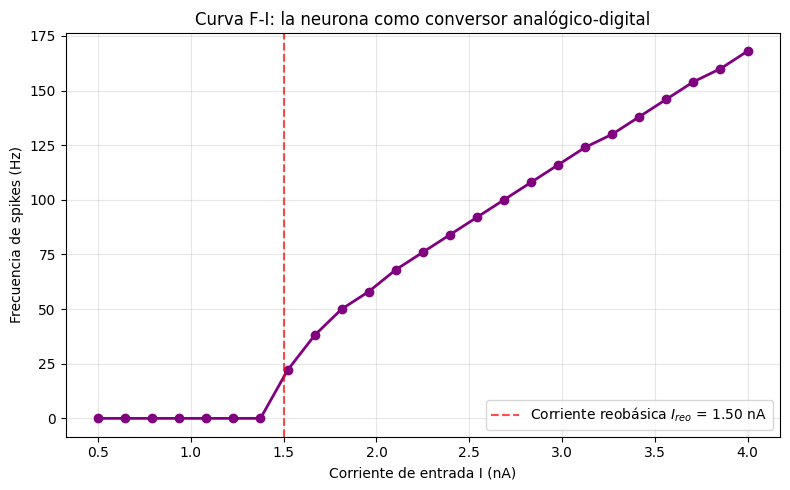

In [3]:
def simular_LIF(I, T_final=500, dt=0.1):
    n = int(T_final / dt)
    V = V_REST
    spikes = []
    for k in range(n):
        V = V + dt * ((-(V - V_REST) + RM * I) / TAU)
        if V >= V_TH:
            spikes.append(k * dt)
            V = V_RESET
    return len(spikes) / (T_final / 1000.0)   # Hz

I_reo_teorica = (V_TH - V_REST) / RM
print(f'Corriente reobásica teórica:  I_reo = {I_reo_teorica:.2f} nA')

corrientes = np.linspace(0.5, 4.0, 25)
frecuencias = [simular_LIF(I) for I in corrientes]
dibujar_curva_FI(corrientes, frecuencias, I_reo=I_reo_teorica)

### 🔍 Experimenta y Reflexiona

- **Anestesia general**: sube `V_TH` a `-50` mV. ¿Cómo cambia la curva F-I? ¿Y la corriente reobásica?
- **Epilepsia**: baja `V_TH` a `-60` mV. ¿Qué ocurre con corrientes que antes no disparaban?
- **Adaptación**: aumenta `TAU` a 30 ms (membrana más "lenta"). ¿Cambia la frecuencia máxima?

---

## 📚 Referencias

**Lapicque, L. (1907).** *Recherches quantitatives sur l'excitation électrique des nerfs traitée comme une polarisation.* Journal de Physiologie et de Pathologie Générale, 9, 620–635. *(modelo original del Integrate-and-Fire)*

**Burkitt, A.N. (2006).** *A review of the integrate-and-fire neuron model: I. Homogeneous synaptic input.* Biological Cybernetics, 95, 1–19.  
[→ DOI: 10.1007/s00422-006-0068-6](https://doi.org/10.1007/s00422-006-0068-6)

**Dayan, P. & Abbott, L.F. (2001).** *Theoretical Neuroscience: Computational and Mathematical Modeling of Neural Systems.* MIT Press.

---

## Mis Respuestas

**Pregunta 1.**

*Escribe aquí tu respuesta...*

---

**Pregunta 2.**

*Escribe aquí tu respuesta...*

---